## Importing datasets from scikit and my goat numpy

In [2]:
from sklearn.datasets import make_classification

## Generate Data Set using scikit

In [16]:
X, Y = make_classification(n_samples=2000, n_classes=2, n_features=10, random_state=0)

## Add noisy features to make the data set more variant

In [5]:
import numpy as np

In [8]:
random_state = np.random.RandomState(0)
n_samples, n_features = X.shape
X = np.c_[X, random_state.randn(n_samples, 200 * n_features)]

## Data Splitting

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=.2, random_state = 0)

## Build Classification model

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

In [13]:
rf = RandomForestClassifier(max_features=5, n_estimators=500)
rf.fit(X_train, Y_train)

RandomForestClassifier(max_features=5, n_estimators=500)

In [14]:
nb = GaussianNB()
nb.fit(X_train, Y_train)

GaussianNB()

## Prediction Probabilities

In [17]:
r_probs = [0 for _ in range(len(Y_test))]
rf_probs = rf.predict_proba(X_test)
nb_probs = nb.predict_proba(X_test)

In [18]:
rf_probs = rf_probs[:,-1]
nb_probs = nb_probs[:,-1]

## Computing AUROC and ROC curve values

In [19]:
from sklearn.metrics import roc_curve, roc_auc_score

### Compute AUC

In [21]:
r_auc = roc_auc_score(Y_test, r_probs)
rf_auc = roc_auc_score(Y_test, rf_probs)
nb_auc = roc_auc_score(Y_test, nb_probs)

In [27]:
print("Random predicion AUROC = %.3f" % (r_auc))
print("Random forest AUROC = %.3f" % (rf_auc))
print("Naive Bayes AUROC = %.3f" % (nb_auc))

Random predicion AUROC = 0.500
Random forest AUROC = 0.928
Naive Bayes AUROC = 0.993


### Calculate the ROC curve

In [28]:
r_fpr, r_tpr, _ = roc_curve(Y_test, r_probs)
rf_fpr, rf_tpr, _ = roc_curve(Y_test, rf_probs)
nb_fpr, nb_tpr, _ = roc_curve(Y_test, nb_probs)

## Plot the ROC curve

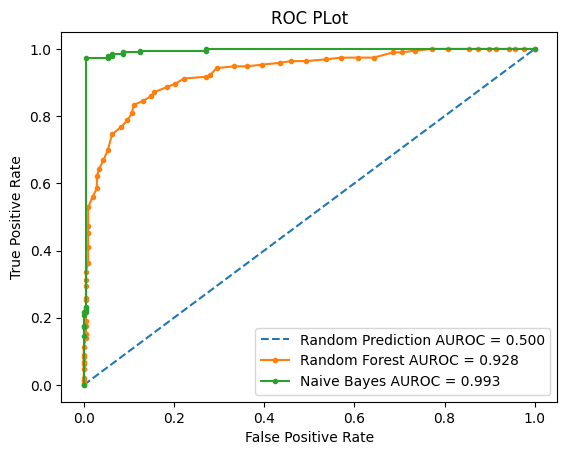

In [30]:
import matplotlib.pyplot as plt
plt.plot(r_fpr, r_tpr, linestyle='--', label="Random Prediction AUROC = %.3f" % (r_auc))
plt.plot(rf_fpr, rf_tpr, marker='.', label="Random Forest AUROC = %.3f" % (rf_auc))
plt.plot(nb_fpr, nb_tpr, marker='.', label="Naive Bayes AUROC = %.3f" % (nb_auc))

# Title
plt.title("ROC PLot")
# Axis labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# Show legend
plt.legend()
# Show plot
plt.show()